In [1]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "pycaret"])

import pycaret
from pycaret.time_series import TSForecastingExperiment

from pycaret.time_series import TSForecastingExperiment as TimeSeriesExperiment

In [2]:
!{sys.executable} -m pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Train/ test
train = df[df.index < '2025-07-13']
test = df[df.index >= '2025-07-13']

covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']
horizonte_test = len(test)

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({len(train)} días)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({len(test)} días)")
print(f"horizonte_test (fh) = {horizonte_test}")

Train: 2013-01-01 → 2025-07-12 (4576 días)
Test:  2025-07-13 → 2026-05-01 (293 días)
horizonte_test (fh) = 293


In [4]:
MODELOS_CLASICOS = [
    'naive', 'grand_means', 'snaive', 'polytrend',   # baseline
    'arima', 'auto_arima',                            # ARIMA / auto-ARIMA (soportan exógenas)
    'exp_smooth', 'ets',                               # suavizamiento exponencial / ETS
    'theta', 'stlf',                                   # Theta / STL Forecaster
    'croston', 'bats', 'tbats',                        # Croston, BATS, TBATS
    'prophet',                                          # Prophet (si está instalado)
]

# Predicción Univariante en test

In [5]:
exp_uni = TSForecastingExperiment()
exp_uni.setup(
    data=df['precio_bolsa'],
    fh=horizonte_test,
    session_id=123,
    verbose=False,
)

# Solo se dejan los IDs de modelos clásicos que realmente están disponibles en este entorno
modelos_disponibles_uni = exp_uni.models().index.tolist()
clasicos_uni = [m for m in MODELOS_CLASICOS if m in modelos_disponibles_uni]
print(f"Modelos clásicos disponibles (univariante): {clasicos_uni}")

best_uni = exp_uni.compare_models(include=clasicos_uni, sort='MASE')
leaderboard_uni = exp_uni.pull()
leaderboard_uni

Modelos clásicos disponibles (univariante): ['naive', 'grand_means', 'snaive', 'polytrend', 'arima', 'auto_arima', 'exp_smooth', 'ets', 'theta', 'stlf', 'croston', 'bats', 'tbats']


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
tbats,TBATS,3.1787,2.1715,300.7717,377.3167,1.0219,0.5671,-0.1774,236.9033
bats,BATS,3.2245,2.1657,306.4933,377.7997,1.0979,0.5692,-0.1558,100.7967
croston,Croston,3.4091,2.2109,326.6670,387.6230,1.3000,0.5791,-0.1185,0.0167
snaive,Seasonal Naive Forecaster,3.5391,2.3598,335.4955,410.6835,1.1930,0.6155,-0.3192,0.9233
stlf,STLF,3.5924,2.3327,343.9204,408.7367,1.3917,0.5939,-0.2543,0.0900
polytrend,Polynomial Trend Forecaster,3.7452,2.6867,347.3454,462.3793,0.7006,0.7284,-0.8629,0.0167
grand_means,Grand Means Forecaster,3.7699,2.7951,350.5636,483.0235,0.5915,0.7317,-1.0210,1.0367
naive,Naive Forecaster,3.8959,2.4664,374.9918,433.5355,1.5319,0.6270,-0.4824,1.3933
exp_smooth,Exponential Smoothing,4.0108,2.5727,385.9743,451.3551,1.5477,0.6389,-0.6114,2.1000
theta,Theta Forecaster,4.0611,2.5597,392.5608,450.9210,1.6294,0.6364,-0.5636,0.8367


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
tbats,TBATS,3.1787,2.1715,300.7717,377.3167,1.0219,0.5671,-0.1774,236.9033
bats,BATS,3.2245,2.1657,306.4933,377.7997,1.0979,0.5692,-0.1558,100.7967
croston,Croston,3.4091,2.2109,326.667,387.623,1.3,0.5791,-0.1185,0.0167
snaive,Seasonal Naive Forecaster,3.5391,2.3598,335.4955,410.6835,1.193,0.6155,-0.3192,0.9233
stlf,STLF,3.5924,2.3327,343.9204,408.7367,1.3917,0.5939,-0.2543,0.0900
polytrend,Polynomial Trend Forecaster,3.7452,2.6867,347.3454,462.3793,0.7006,0.7284,-0.8629,0.0167
grand_means,Grand Means Forecaster,3.7699,2.7951,350.5636,483.0235,0.5915,0.7317,-1.021,1.0367
naive,Naive Forecaster,3.8959,2.4664,374.9918,433.5355,1.5319,0.627,-0.4824,1.3933
exp_smooth,Exponential Smoothing,4.0108,2.5727,385.9743,451.3551,1.5477,0.6389,-0.6114,2.1000
theta,Theta Forecaster,4.0611,2.5597,392.5608,450.921,1.6294,0.6364,-0.5636,0.8367


Mejor modelo univariante: tbats  (TBATS)


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,TBATS,0.8093,0.5632,97.2152,126.4157,0.3569,0.4637,-0.9755


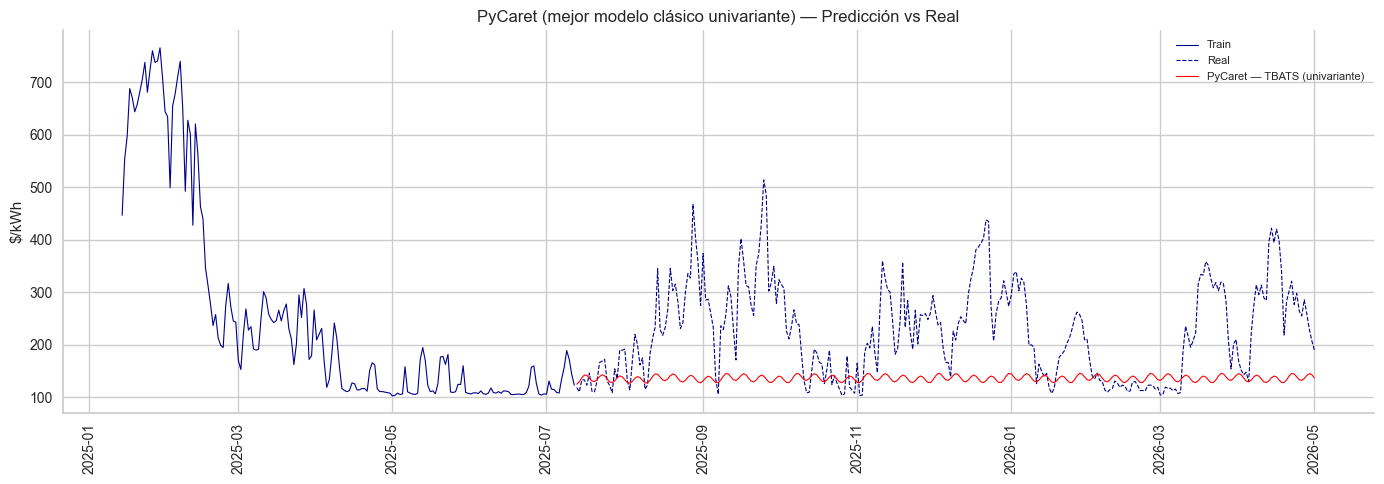

In [6]:
print(f"Mejor modelo univariante: {exp_uni.pull().index[0]}  ({type(best_uni).__name__})")

pred_uni = exp_uni.predict_model(best_uni)
pred_timesfm_uni = pred_uni['y_pred']
pred_timesfm_uni.index = test.index  # alinear con las fechas reales de test

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(pred_timesfm_uni.index, pred_timesfm_uni, color='red', linewidth=0.8, label=f'PyCaret — {type(best_uni).__name__} (univariante)')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('PyCaret (mejor modelo clásico univariante) — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

# Predicción con covariables en test

In [7]:
data_cov = df[['precio_bolsa'] + covariables]

exp_cov = TSForecastingExperiment()
exp_cov.setup(
    data=data_cov,
    target='precio_bolsa',
    fh=horizonte_test,
    session_id=123,
    enforce_exogenous=True,
    numeric_imputation_exogenous='ffill',
    verbose=False,
)

modelos_disponibles_cov = exp_cov.models().index.tolist()
clasicos_cov = [m for m in MODELOS_CLASICOS if m in modelos_disponibles_cov]
print(f"Modelos clásicos disponibles (con covariables): {clasicos_cov}")

best_cov = exp_cov.compare_models(include=clasicos_cov, sort='MASE')
leaderboard_cov = exp_cov.pull()
leaderboard_cov

Modelos clásicos disponibles (con covariables): ['arima', 'auto_arima', 'croston']


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
arima,ARIMA,2.2652,1.5662,213.1509,272.5360,0.7348,0.4526,0.4138,6.6300
croston,Croston,3.4091,2.2109,326.6670,387.6230,1.3000,0.5791,-0.1185,0.1400
auto_arima,Auto ARIMA,nan,nan,nan,nan,nan,nan,nan,269.3033


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
arima,ARIMA,2.2652,1.5662,213.1509,272.536,0.7348,0.4526,0.4138,6.6300
croston,Croston,3.4091,2.2109,326.667,387.623,1.3,0.5791,-0.1185,0.1400
auto_arima,Auto ARIMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,269.3033


Mejor modelo con covariables: arima  (ARIMA)


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ARIMA,0.5171,0.3520,62.1126,79.0110,0.2686,0.3286,0.2283


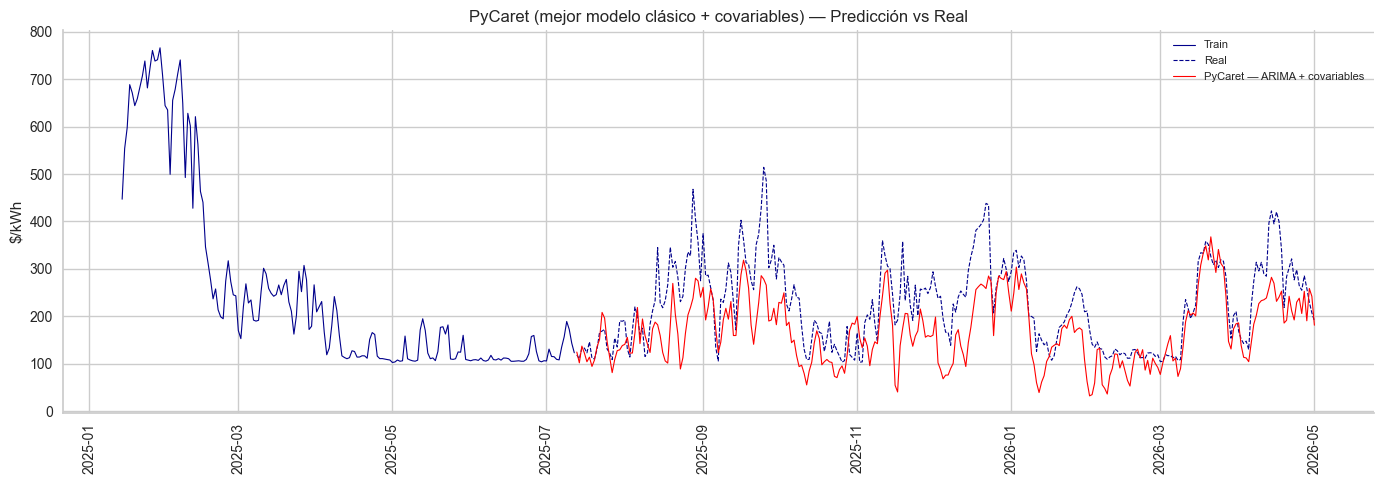

In [8]:
print(f"Mejor modelo con covariables: {exp_cov.pull().index[0]}  ({type(best_cov).__name__})")

pred_cov = exp_cov.predict_model(best_cov)
pred_timesfm_cov = pred_cov['y_pred']
pred_timesfm_cov.index = test.index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(pred_timesfm_cov.index, pred_timesfm_cov, color='red', linewidth=0.8, label=f'PyCaret — {type(best_cov).__name__} + covariables')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('PyCaret (mejor modelo clásico + covariables) — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

## Tabla comparativa: Modelos Clásicos

In [9]:
resultados_pycaret = {
    f"PyCaret {type(best_uni).__name__} (univariante)": leaderboard_uni.iloc[0][
        ['MASE', 'RMSSE', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2', 'TT (Sec)']
    ].to_dict(),
    f"PyCaret {type(best_cov).__name__} (+ covariables)": leaderboard_cov.iloc[0][
        ['MASE', 'RMSSE', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2', 'TT (Sec)']
    ].to_dict(),
}

pd.DataFrame(resultados_pycaret).T

,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
PyCaret TBATS (univariante),3.1787,2.1715,300.7717,377.3167,1.0219,0.5671,-0.1774,236.9033
PyCaret ARIMA (+ covariables),2.2652,1.5662,213.1509,272.5360,0.7348,0.4526,0.4138,6.6300


# Predicción a un horizonte futuro

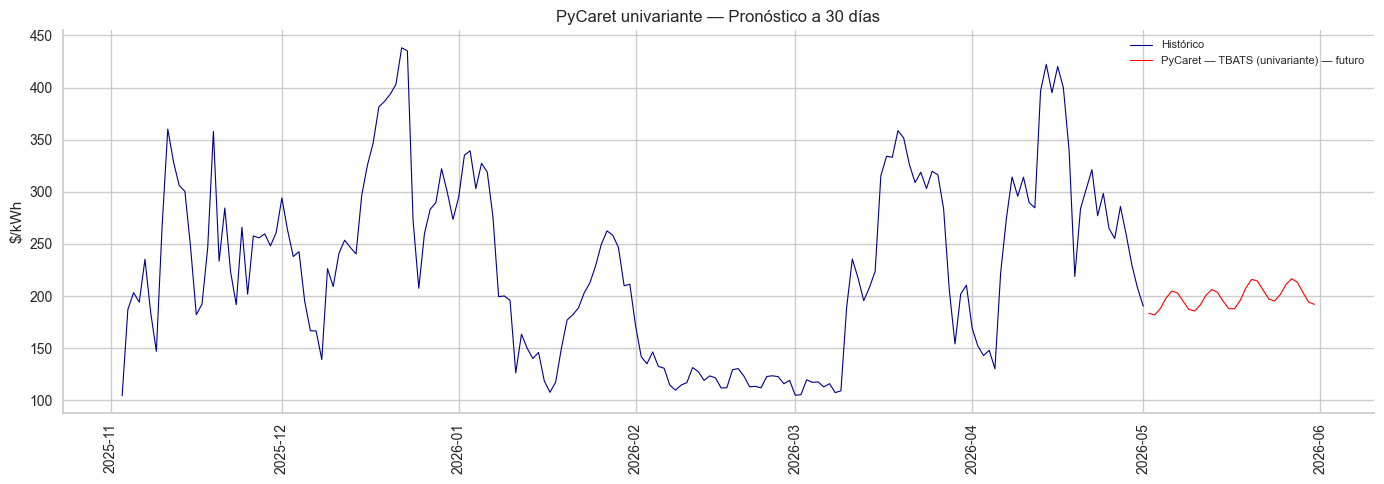

In [10]:
horizonte_futuro = 30  # días a pronosticar hacia adelante

final_uni = exp_uni.finalize_model(best_uni)
pred_futuro_uni = exp_uni.predict_model(final_uni, fh=horizonte_futuro)
pred_futuro_uni = pred_futuro_uni['y_pred']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(pred_futuro_uni.index, pred_futuro_uni, color='red', linewidth=0.8, label=f'PyCaret — {type(best_uni).__name__} (univariante) — futuro')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'PyCaret univariante — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

# Generar el índice de fechas futuras
freq = pd.infer_freq(df.index) or 'D'
fechas_futuras = pd.date_range(
    start=df.index[-1] + pd.tseries.frequencies.to_offset(freq),
    periods=horizonte_futuro,
    freq=freq
)

# Aproximación: como no tenemos el valor real futuro de las covariables,
# usamos el último valor observado para cada una.
# - ONI cambia muy lento (mensual) -> persistencia es razonable
# - gen_termica y aportes_energia_gwh: si tienes forecast propio, reemplázalo aquí;
#   de lo contrario, usamos el promedio de los últimos 30 días como estimación más estable
df_covariables_futuras = pd.DataFrame(index=fechas_futuras, columns=covariables, dtype=float)

df_covariables_futuras['ONI'] = df['ONI'].iloc[-1]  # persistencia (cambia poco)
df_covariables_futuras['gen_termica'] = df['gen_termica'].iloc[-30:].mean()
df_covariables_futuras['aportes_energia_gwh'] = df['aportes_energia_gwh'].iloc[-30:].mean()

print(df_covariables_futuras)

In [ ]:
final_cov = exp_cov.finalize_model(best_cov)
pred_futuro_cov = exp_cov.predict_model(final_cov, fh=horizonte_futuro, X=df_covariables_futuras)
pred_futuro_cov = pred_futuro_cov['y_pred']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Histórico')
ax.plot(pred_futuro_uni.index, pred_futuro_uni, color='red', linewidth=0.8, linestyle='--', label=f'PyCaret univariante — futuro')
ax.plot(pred_futuro_cov.index, pred_futuro_cov, color='green', linewidth=0.8, label='PyCaret + covariables — futuro')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'PyCaret univariante vs con covariables — Pronóstico a {horizonte_futuro} días')
sns.despine()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'univariante': pred_futuro_uni, 'con_covariables': pred_futuro_cov}))

NameError: name 'df_covariables_futuras' is not defined